In [1]:
import torch
from torch.nn import ModuleList
import numpy as np
import torch.nn as nn
from scipy.spatial import cKDTree as KDTree
import os
import glob
import pandas as pd
import math
from typing import Optional, Tuple, Dict
import torch.nn.functional as F

device = torch.device('cpu')
torch.set_default_dtype(torch.float32)

In [2]:
class RelTrLoc(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.translation_projection = nn.Sequential(
            nn.Linear(in_channels,in_channels),
            nn.ReLU(),
            nn.Linear(in_channels,in_channels),
            nn.ReLU(),
            nn.Linear(in_channels,out_channels))

    def forward(self,x1,x2):
        transform = self.translation_projection(x2-x1)
        return transform

def equivariant_translation(tx1, ty1, tz1, tx2, ty2, tz2, u1, v1, w1, u2, v2, w2, eps=1e-9):
    # World displacement from cam1 to cam2
    dp = np.array([tx2 - tx1, ty2 - ty1, tz2 - tz1], dtype=float)

    # Cam1 forward (+z) in world
    z = np.array([u1, v1, w1], dtype=float)
    z_norm = np.linalg.norm(z)
    z /= z_norm

    # World up
    uw = np.array([0.0, 1.0, 0.0], dtype=float)

    # Right (+x) = normalize(uw x z); fallback if degenerate
    x = np.cross(uw, z)
    x_norm = np.linalg.norm(x)
    if x_norm < eps:
        # forward is ~parallel to world-up; choose a fallback up
        uw_fallback = np.array([0.0, 0.9, 0.0], dtype=float)
        x = np.cross(uw_fallback, z)
        x_norm = np.linalg.norm(x)
        if x_norm < eps:
            raise ValueError("Degenerate orientation: cannot construct basis.")
    x /= x_norm

    # Up (+y) = z x x  (ensures right-handed basis)
    y = np.cross(z, x)

    # Rotation camera --> world, columns are camera axes in world
    R_cw = np.column_stack((x, y, z))

    # displacement in camera 1 coordinates: t = R_wc * dp = R_cw.T * dp
    t_c1 = R_cw.T @ dp
    t_c1 = torch.tensor(t_c1)
    rot1 = torch.tensor([u2-u1,v2-v1,w2-w1])
    return t_c1, rot1

In [ ]:
# pairs already saved in rw_latents
def test_loader(rw:int,idx1):
    data = torch.load(f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/rw_latents/z_img_rw_{rw}.pt')
    pairs = data.edge_index.T
    idx2 = idx1+1
    p1 = torch.load(f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/rw_latents/z_img/rw_{rw}_{idx1}.pt')
    p2 = torch.load(f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/rw_latents/z_img/rw_{rw}_{idx2}.pt')
    
    return p1['latent'], p2['latent'], p1['loc'], p2['loc'], p1['viewdir'], p2['viewdir']

model = RelTrLoc(in_channels=128,out_channels=6).to(device)
alias = '0220_translation_rotation'
model_weights = f"../../../../scratch/btuncay/cog/gnn_spatial_reasoning/model_movement/{alias}/model_weights_9800.pt"
state = torch.load(model_weights, map_location=device)
model.load_state_dict(state)
model.eval()

def run_inference(i: int):
    results = []

    sum_pred = torch.zeros(1,6, device=device)
    sum_tc1  = torch.zeros(3, device=device)
    sum_rot  = torch.zeros(3, device=device)
    sum_j    = 0

    for j in range(39):
        l1, l2, p1loc, p2loc, p1dir, p2dir = test_loader(i, j)
        tx1, ty1, tz1 = p1loc
        tx2, ty2, tz2 = p2loc
        u1, v1, w1 = p1dir
        u2, v2, w2 = p2dir
        t_c1, rot = equivariant_translation(tx1, ty1, tz1, tx2, ty2, tz2, u1, v1, w1, u2, v2, w2)
        t_c1 = t_c1.float().to(device)
        rot  = rot.float().to(device)
        l1   = l1.to(device)
        l2   = l2.to(device)
        with torch.no_grad():
            pred = model(l1, l2)

        sum_pred += pred
        sum_tc1  += t_c1
        sum_rot  += rot
        sum_j    += j

        results.append((sum_pred.clone(),sum_tc1.clone(),
                        sum_rot.clone(),sum_j))

    return results

results = run_inference(3)
preds = torch.stack([r[0] for r in results])   # (N, 6)
tc1s  = torch.stack([r[1] for r in results])   # (N, 3)
rots  = torch.stack([r[2] for r in results])   # (N, 3)
js    = torch.tensor([r[3] for r in results], device=preds.device)
pred = torch.cat([preds[:,0,:],tc1s,rots],dim=-1)
#print(pred)

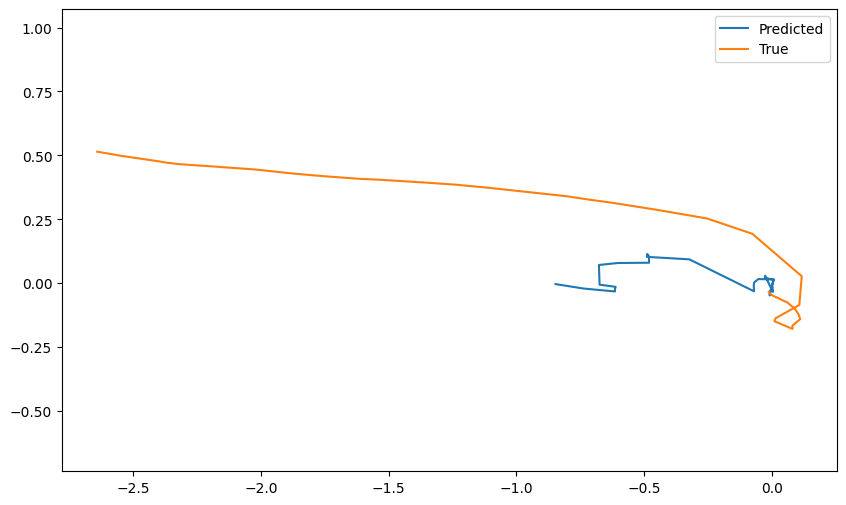

In [51]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.axis('equal')
plt.plot(pred[:,1],pred[:,0],label='Predicted')
plt.plot(pred[:,7],pred[:,6],label='True')
plt.legend()